# 📊 Module 5: EWRI (ESG-Washing Risk Index)

Calculate ESG-washing risk scores for each bank-year.

**Formula:** `EWRI = Symbolic_Ratio × (1 - Evidence_Ratio) × 100`
- High EWRI → High washing risk
- Low EWRI → Substantive disclosure

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from ewri.ewri import calculate_bank_year_ewri, scores_to_dataframe, get_risk_level

INPUT_PATH = Path("../data/corpus/esg_sentences_with_evidence.parquet")
OUTPUT_DIR = Path("../outputs")

print("EWRI Formula: Symbolic_Ratio × (1 - Evidence_Ratio) × 100")

EWRI Formula: Symbolic_Ratio × (1 - Evidence_Ratio) × 100


## 1️⃣ Load Data

In [2]:
df = pd.read_parquet(INPUT_PATH)
print(f"Total ESG sentences: {len(df):,}")
print(f"Banks: {df['bank'].nunique()}")
print(f"Years: {sorted(df['year'].unique())}")

Total ESG sentences: 40,372
Banks: 10
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 2️⃣ Calculate EWRI Scores

In [3]:
# Calculate EWRI for each bank-year
scores = calculate_bank_year_ewri(df)
df_ewri = scores_to_dataframe(scores)

# Sort by EWRI descending
df_ewri = df_ewri.sort_values("ewri", ascending=False)

print(f"Total bank-years: {len(df_ewri)}")
print(f"Average EWRI: {df_ewri['ewri'].mean():.2f}")
print(f"EWRI Range: {df_ewri['ewri'].min():.2f} - {df_ewri['ewri'].max():.2f}")

Total bank-years: 49
Average EWRI: 50.72
EWRI Range: 35.87 - 100.00


In [4]:
# Full table
display_cols = ["bank", "year", "total_sentences", "symbolic_ratio", "evidence_ratio", "ewri", "risk_level"]
print("\n=== EWRI SCORES BY BANK-YEAR ===")
print(df_ewri[display_cols].to_string(index=False))


=== EWRI SCORES BY BANK-YEAR ===
       bank  year  total_sentences  symbolic_ratio  evidence_ratio   ewri risk_level
  vietabank  2022                2           1.000           0.000 100.00  Very High
        bsc  2020              215           0.926           0.028  89.98  Very High
vietcombank  2021              244           0.820           0.168  68.19       High
  vietabank  2021               14           0.857           0.214  67.35       High
vietcombank  2020              274           0.810           0.182  66.24       High
        bsc  2024              643           0.849           0.233  65.11       High
        bsc  2023              541           0.835           0.229  64.40       High
        bsc  2022              532           0.831           0.233  63.72       High
vietcombank  2024              314           0.815           0.229  62.83       High
        bsc  2021              538           0.822           0.257  61.08       High
techcombank  2023             1

## 3️⃣ Risk Level Distribution

=== RISK LEVEL DISTRIBUTION ===
risk_level
Medium       31
High         16
Very High     2
Name: count, dtype: int64


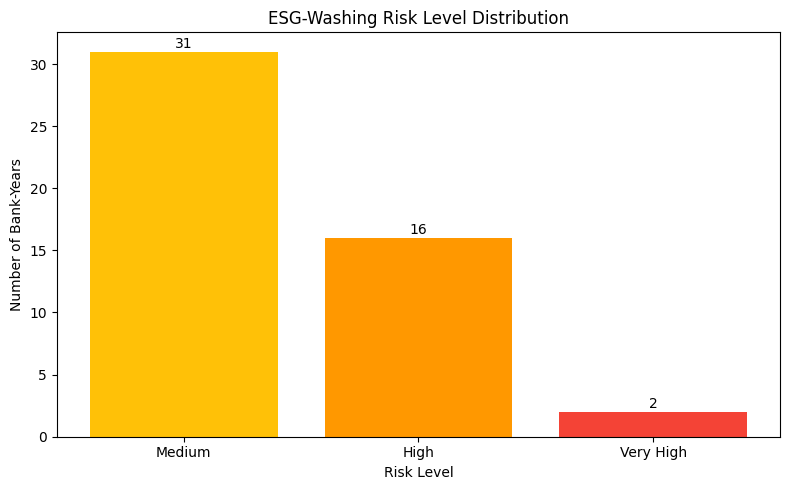

In [5]:
# Risk level counts
risk_counts = df_ewri["risk_level"].value_counts()
print("=== RISK LEVEL DISTRIBUTION ===")
print(risk_counts)

# Visualization
colors = {"Low": "#4CAF50", "Medium": "#FFC107", "High": "#FF9800", "Very High": "#F44336"}
plt.figure(figsize=(8, 5))
risk_order = ["Low", "Medium", "High", "Very High"]
risk_counts_ordered = risk_counts.reindex([r for r in risk_order if r in risk_counts.index])
bars = plt.bar(risk_counts_ordered.index, risk_counts_ordered.values, 
               color=[colors[r] for r in risk_counts_ordered.index])
plt.title("ESG-Washing Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Bank-Years")
for bar, v in zip(bars, risk_counts_ordered.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v), ha='center')
plt.tight_layout()
plt.show()

## 4️⃣ EWRI Heatmap: Bank × Year

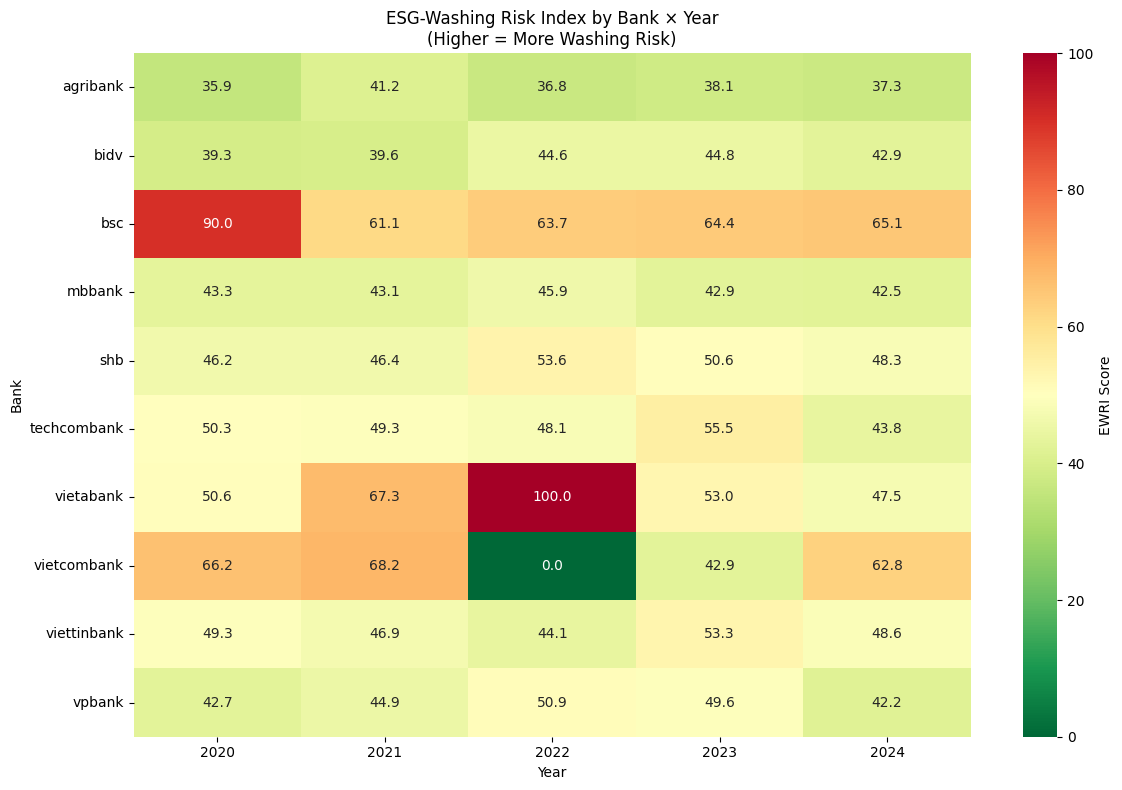

In [6]:
# Pivot table
pivot = df_ewri.pivot(index="bank", columns="year", values="ewri").fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", 
            cbar_kws={"label": "EWRI Score"}, vmin=0, vmax=100)
plt.title("ESG-Washing Risk Index by Bank × Year\n(Higher = More Washing Risk)")
plt.xlabel("Year")
plt.ylabel("Bank")
plt.tight_layout()
plt.show()

## 5️⃣ Top/Bottom Rankings

In [7]:
print("=" * 60)
print("TOP 10 HIGHEST EWRI (Highest Washing Risk)")
print("=" * 60)
print(df_ewri.head(10)[display_cols].to_string(index=False))

print("\n" + "=" * 60)
print("TOP 10 LOWEST EWRI (Most Substantive)")
print("=" * 60)
print(df_ewri.tail(10)[display_cols].to_string(index=False))

TOP 10 HIGHEST EWRI (Highest Washing Risk)
       bank  year  total_sentences  symbolic_ratio  evidence_ratio   ewri risk_level
  vietabank  2022                2           1.000           0.000 100.00  Very High
        bsc  2020              215           0.926           0.028  89.98  Very High
vietcombank  2021              244           0.820           0.168  68.19       High
  vietabank  2021               14           0.857           0.214  67.35       High
vietcombank  2020              274           0.810           0.182  66.24       High
        bsc  2024              643           0.849           0.233  65.11       High
        bsc  2023              541           0.835           0.229  64.40       High
        bsc  2022              532           0.831           0.233  63.72       High
vietcombank  2024              314           0.815           0.229  62.83       High
        bsc  2021              538           0.822           0.257  61.08       High

TOP 10 LOWEST EWRI (M

## 6️⃣ Year-over-Year Trend

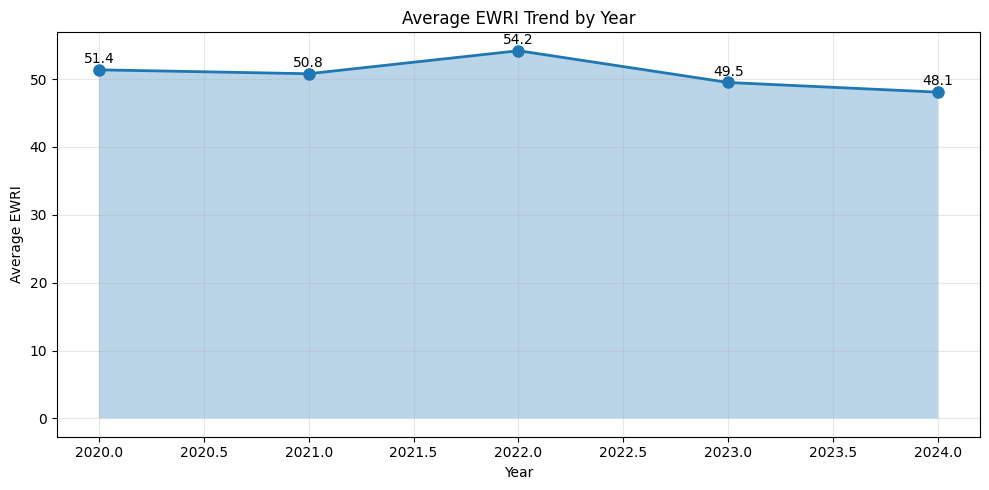

Year-over-Year EWRI:
year
2020    51.38
2021    50.80
2022    54.19
2023    49.51
2024    48.08
Name: ewri, dtype: float64


In [8]:
# Average EWRI by year
year_avg = df_ewri.groupby("year")["ewri"].mean()

plt.figure(figsize=(10, 5))
plt.plot(year_avg.index, year_avg.values, marker='o', linewidth=2, markersize=8)
plt.fill_between(year_avg.index, year_avg.values, alpha=0.3)
plt.title("Average EWRI Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average EWRI")
plt.grid(True, alpha=0.3)
for x, y in zip(year_avg.index, year_avg.values):
    plt.text(x, y + 1, f"{y:.1f}", ha='center')
plt.tight_layout()
plt.show()

print("Year-over-Year EWRI:")
print(year_avg.round(2))

## 7️⃣ Bank Comparison (Average across years)

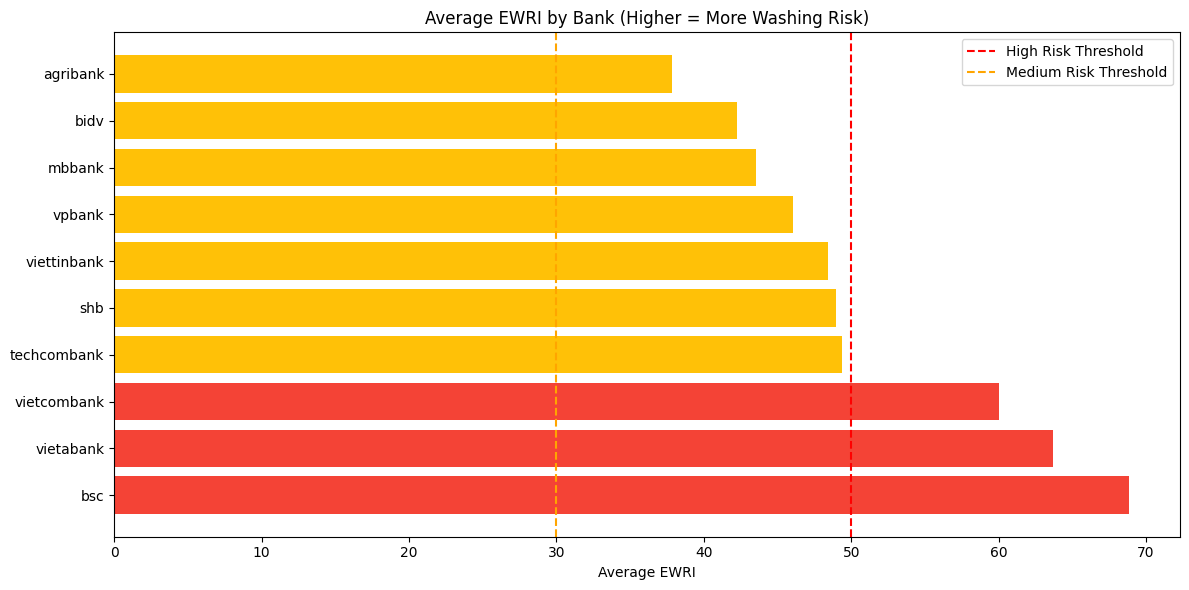


Bank Rankings (by average EWRI):
 1. bsc             EWRI: 68.86  [High]
 2. vietabank       EWRI: 63.70  [High]
 3. vietcombank     EWRI: 60.05  [High]
 4. techcombank     EWRI: 49.37  [Medium]
 5. shb             EWRI: 49.00  [Medium]
 6. viettinbank     EWRI: 48.44  [Medium]
 7. vpbank          EWRI: 46.06  [Medium]
 8. mbbank          EWRI: 43.54  [Medium]
 9. bidv            EWRI: 42.24  [Medium]
10. agribank        EWRI: 37.84  [Medium]


In [9]:
# Average EWRI by bank
bank_avg = df_ewri.groupby("bank")["ewri"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ["#F44336" if v > 50 else "#FFC107" if v > 30 else "#4CAF50" for v in bank_avg.values]
bars = plt.barh(bank_avg.index, bank_avg.values, color=colors)
plt.axvline(x=50, color='red', linestyle='--', label='High Risk Threshold')
plt.axvline(x=30, color='orange', linestyle='--', label='Medium Risk Threshold')
plt.title("Average EWRI by Bank (Higher = More Washing Risk)")
plt.xlabel("Average EWRI")
plt.legend()
plt.tight_layout()
plt.show()

print("\nBank Rankings (by average EWRI):")
for i, (bank, ewri) in enumerate(bank_avg.items(), 1):
    level = get_risk_level(ewri)
    print(f"{i:2}. {bank:15} EWRI: {ewri:5.2f}  [{level}]")

## 8️⃣ Correlation Analysis

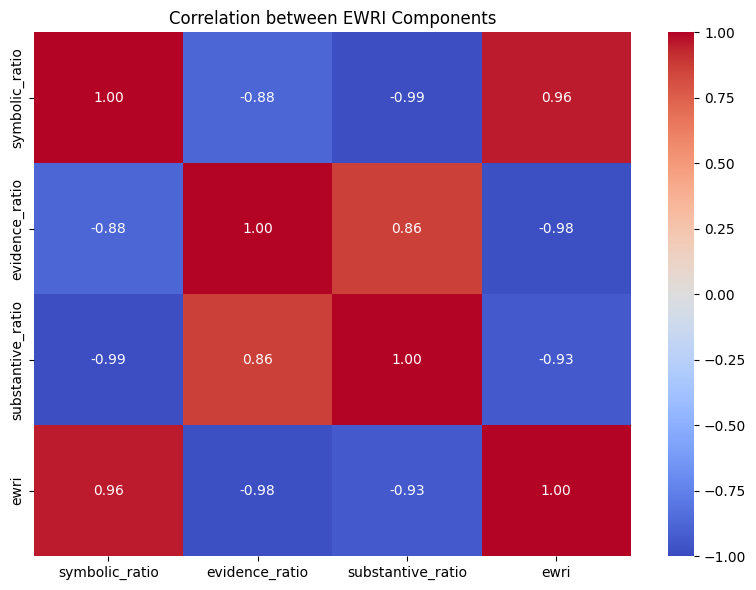

In [10]:
# Correlation between components
corr_cols = ["symbolic_ratio", "evidence_ratio", "substantive_ratio", "ewri"]
corr = df_ewri[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between EWRI Components")
plt.tight_layout()
plt.show()

## 9️⃣ Save Results

In [11]:
# Save EWRI scores
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df_ewri.to_csv(OUTPUT_DIR / "ewri_scores.csv", index=False)
print(f"✅ Saved: {OUTPUT_DIR / 'ewri_scores.csv'}")

# Save bank rankings
bank_avg.to_csv(OUTPUT_DIR / "ewri_bank_rankings.csv")
print(f"✅ Saved: {OUTPUT_DIR / 'ewri_bank_rankings.csv'}")

✅ Saved: ../outputs/ewri_scores.csv
✅ Saved: ../outputs/ewri_bank_rankings.csv


## 📊 Summary for Paper

In [12]:
print("="*60)
print("EWRI ANALYSIS COMPLETE")
print("="*60)
print(f"\nFormula: EWRI = Symbolic_Ratio × (1 - Evidence_Ratio) × 100")
print(f"\nTotal bank-years analyzed: {len(df_ewri)}")
print(f"Average EWRI: {df_ewri['ewri'].mean():.2f}")
print(f"EWRI Range: {df_ewri['ewri'].min():.2f} - {df_ewri['ewri'].max():.2f}")

print("\nRisk Level Distribution:")
for level in ["Low", "Medium", "High", "Very High"]:
    count = (df_ewri["risk_level"] == level).sum()
    print(f"  {level:10} {count:3}")

print("\nHighest EWRI (Most Washing Risk):")
top = df_ewri.iloc[0]
print(f"  {top['bank']} ({int(top['year'])}): EWRI = {top['ewri']:.2f}")

print("\nLowest EWRI (Most Substantive):")
bottom = df_ewri.iloc[-1]
print(f"  {bottom['bank']} ({int(bottom['year'])}): EWRI = {bottom['ewri']:.2f}")

EWRI ANALYSIS COMPLETE

Formula: EWRI = Symbolic_Ratio × (1 - Evidence_Ratio) × 100

Total bank-years analyzed: 49
Average EWRI: 50.72
EWRI Range: 35.87 - 100.00

Risk Level Distribution:
  Low          0
  Medium      31
  High        16
  Very High    2

Highest EWRI (Most Washing Risk):
  vietabank (2022): EWRI = 100.00

Lowest EWRI (Most Substantive):
  agribank (2020): EWRI = 35.87
